In [1]:
import os
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


os.makedirs("./artifacts", exist_ok=True)

RANDOM_STATE = 42
MODEL_NAME = "distilbert-base-uncased"

set_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [2]:
dataset = load_dataset("emotion")

In [3]:
print("Размеры датасета:")
print(f"Train: {len(dataset['train'])}")
print(f"Validation: {len(dataset['validation'])}")
print(f"Test: {len(dataset['test'])}")

Размеры датасета:
Train: 16000
Validation: 2000
Test: 2000


In [4]:
label_names = dataset["train"].features["label"].names

pd.DataFrame({
    "text": dataset["train"]["text"][:15],
    "label_id": dataset["train"]["label"][:15],
        "class_name": [label_names[i] for i in dataset["train"]["label"][:15]]

})

,text,label_id,class_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasnt sure why that was,0,sadness
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,5,surprise
7,i feel as confused about life as a teenager or as jaded as a year old man,4,fear
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,1,joy
9,i feel romantic too,2,love


In [5]:
unique_labels = set(dataset["train"]["label"])
print(f"Уникальные классы: {unique_labels}")

Уникальные классы: {0, 1, 2, 3, 4, 5}


- Задача: классификация текстов по эмоциональной окраске
- Данные: датасет `emotion`
- Классы эмоций:
    - Радость — позитивные, счастливые тексты
    - Любовь — тексты с выражением привязанности
    - Гнев — агрессивные, негативные тексты
    - Грусть — печальные, меланхоличные тексты
    - Страх — тревожные, пугающие тексты
    - Удивление — тексты, выражающие изумление

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [7]:
sample_texts = dataset["train"]["text"][:15]
sample_labels = [label_names[i] for i in dataset["train"]["label"][:15]]

data = []

for text, label in zip(sample_texts, sample_labels):
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=True)
    encoded = tokenizer(text, padding=False, truncation=False)
    
    data.append({
        "text": text,
        "label": label,
        "tokens": tokens,
        "input_ids": token_ids,
        "attention_mask": encoded["attention_mask"],
        "num_tokens": len(tokens)
    })

pd.DataFrame(data)

,text,label,tokens,input_ids,attention_mask,num_tokens
0,i didnt feel humiliated,sadness,"[i, didn, ##t, feel, humiliated]","[101, 1045, 2134, 2102, 2514, 26608, 102]","[1, 1, 1, 1, 1, 1, 1]",5
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,"[i, can, go, from, feeling, so, hopeless, to, so, damned, hopeful, just, from, being, around, someone, who, cares, and, is, awake]","[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",21
2,im grabbing a minute to post i feel greedy wrong,anger,"[im, grabbing, a, minute, to, post, i, feel, greedy, wrong]","[101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",10
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love,"[i, am, ever, feeling, nos, ##tal, ##gic, about, the, fireplace, i, will, know, that, it, is, still, on, the, property]","[101, 1045, 2572, 2412, 3110, 16839, 9080, 12863, 2055, 1996, 13788, 1045, 2097, 2113, 2008, 2009, 2003, 2145, 2006, 1996, 3200, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",20
4,i am feeling grouchy,anger,"[i, am, feeling, gr, ##ou, ##chy]","[101, 1045, 2572, 3110, 24665, 7140, 11714, 102]","[1, 1, 1, 1, 1, 1, 1, 1]",6
5,ive been feeling a little burdened lately wasnt sure why that was,sadness,"[iv, ##e, been, feeling, a, little, burden, ##ed, lately, wasn, ##t, sure, why, that, was]","[101, 4921, 2063, 2042, 3110, 1037, 2210, 10859, 2098, 9906, 2347, 2102, 2469, 2339, 2008, 2001, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",15
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,surprise,"[iv, ##e, been, taking, or, mill, ##ig, ##ram, ##s, or, times, recommended, amount, and, iv, ##e, fallen, asleep, a, lot, faster, but, i, also, feel, like, so, funny]","[101, 4921, 2063, 2042, 2635, 2030, 4971, 8004, 6444, 2015, 2030, 2335, 6749, 3815, 1998, 4921, 2063, 5357, 6680, 1037, 2843, 5514, 2021, 1045, 2036, 2514, 2066, 2061, 6057, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",28
7,i feel as confused about life as a teenager or as jaded as a year old man,fear,"[i, feel, as, confused, about, life, as, a, teenager, or, as, jade, ##d, as, a, year, old, man]","[101, 1045, 2514, 2004, 5457, 2055, 2166, 2004, 1037, 10563, 2030, 2004, 12323, 2094, 2004, 1037, 2095, 2214, 2158, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",18
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,joy,"[i, have, been, with, pet, ##rona, ##s, for, years, i, feel, that, pet, ##rona, ##s, has, performed, well, and, made, a, huge, profit]","[101, 1045, 2031, 2042, 2007, 9004, 26788, 2015, 2005, 2086, 1045, 2514, 2008, 9004, 26788, 2015, 2038, 2864, 2092, 1998, 2081, 1037, 4121, 5618, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",23
9,i feel romantic too,love,"[i, feel, romantic, too]","[101, 1045, 2514, 6298, 2205, 102]","[1, 1, 1, 1, 1, 1]",4


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
).to(device)
model

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [9]:
test_texts = dataset["validation"]["text"][:]
true_labels_names = [label_names[i] for i in dataset["validation"]["label"][:]]

inputs = tokenizer(test_texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

predicted_labels_names = [label_names[p] for p in predictions]

In [12]:
inference_results = pd.DataFrame({
    "text": [t for t in test_texts],
    "true_label": true_labels_names,
    "predicted_label": predicted_labels_names,
    "correct": [t == p for t, p in zip(true_labels_names, predicted_labels_names)]
})

correct_count = inference_results["correct"].sum()
print(f"Accuracy: {correct_count}/2000 ({correct_count / 2000 * 100})")
inference_results

Accuracy: 272/2000 (13.600000000000001)


,text,true_label,predicted_label,correct
0,im feeling quite sad and sorry for myself but ill snap out of it soon,sadness,anger,False
1,i feel like i am still looking at a blank canvas blank pieces of paper,sadness,anger,False
2,i feel like a faithful servant,love,anger,False
3,i am just feeling cranky and blue,anger,anger,True
4,i can have for a treat or if i am feeling festive,joy,anger,False
...,...,...,...,...
1995,im having ssa examination tomorrow in the morning im quite well prepared for the coming exam and somehow i feel numb towards exam because in life there is much more important things than exam,sadness,anger,False
1996,i constantly worry about their fight against nature as they push the limits of their inner bodies for the determination of their outer existence but i somehow feel reassured,joy,anger,False
1997,i feel its important to share this info for those that experience the same thing,joy,anger,False
1998,i truly feel that if you are passionate enough about something and stay true to yourself you will succeed,joy,anger,False


<Axes: >

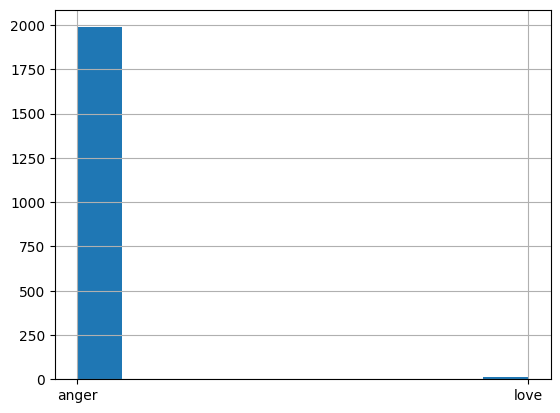

In [14]:
inference_results.predicted_label.hist()

In [15]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    f1_weighted = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

In [17]:
common_training_kwargs = dict(
    output_dir="./.output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to="none"
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        **common_training_kwargs
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        **common_training_kwargs
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.456485,0.243982,0.928000,0.901425,0.928737
2,0.328474,0.193062,0.938500,0.908914,0.937641
3,0.001419,0.224794,0.938000,0.914712,0.938607
4,0.077311,0.269853,0.936000,0.914479,0.936176
5,0.000259,0.284043,0.940000,0.913757,0.939768


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=10000, training_loss=0.17400189336113836, metrics={'train_runtime': 602.8858, 'train_samples_per_second': 132.695, 'train_steps_per_second': 16.587, 'total_flos': 2649536962560000.0, 'train_loss': 0.17400189336113836, 'epoch': 5.0})

In [19]:
test_results = trainer.evaluate(tokenized_datasets["test"])
predictions = trainer.predict(tokenized_datasets["test"])
true_labels = tokenized_datasets["test"]["label"]
predicted_labels = np.argmax(predictions.predictions, axis=-1)

predicted_labels

array([0, 0, 0, ..., 1, 1, 5], shape=(2000,))

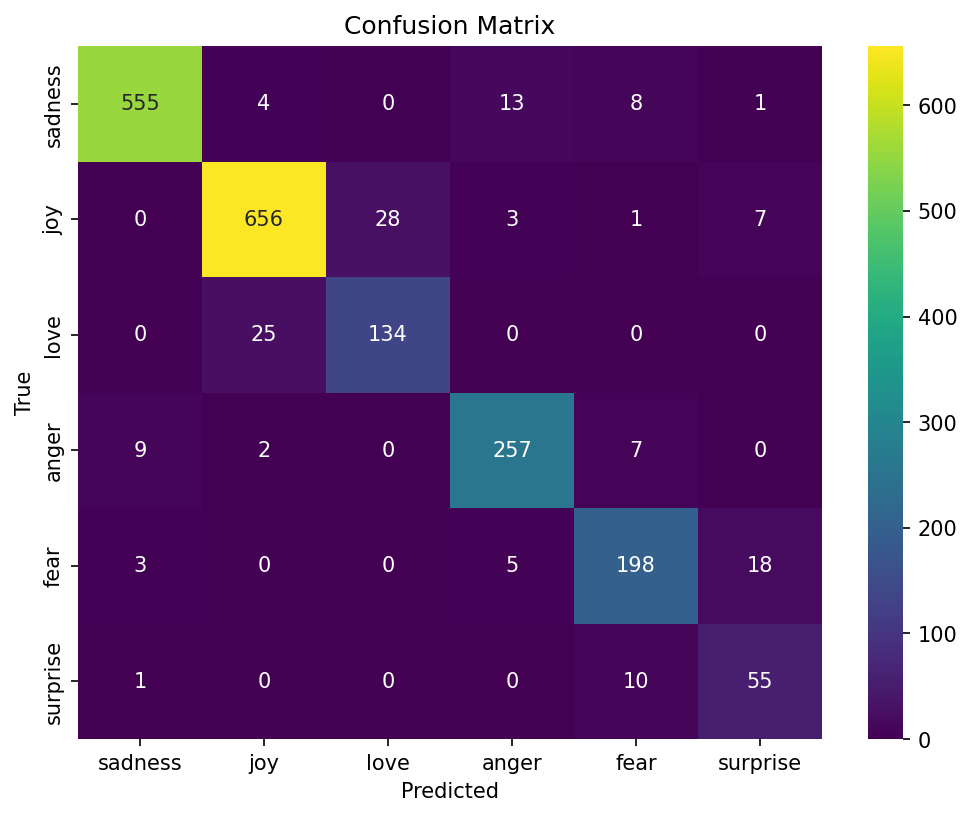

In [20]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="viridis",
    xticklabels=dataset["train"].features["label"].names,
    yticklabels=dataset["train"].features["label"].names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

In [21]:
results_df = pd.DataFrame({
    "text": tokenized_datasets["test"]["text"],
    "true_label": [label_names[l] for l in true_labels],
    "pred_label": [label_names[p] for p in predicted_labels]
})
results_df.to_csv("./artifacts/sample_predictions.csv", index=False)
results_df.head(n=50)

,text,true_label,pred_label
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness
1,im updating my blog because i feel shitty,sadness,sadness
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy
4,i was feeling a little vain when i did this one,sadness,sadness
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear
6,i felt anger when at the end of a telephone call,anger,anger
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia,joy,joy
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer,anger,anger


In [22]:
accuracy = test_results["eval_accuracy"]
f1_macro = test_results["eval_f1_macro"]
f1_weighted = test_results["eval_f1_weighted"]

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Accuracy: 0.9275
F1 Macro: 0.8853
F1 Weighted: 0.9284


In [23]:
error_df = results_df[results_df["true_label"] != results_df["pred_label"]]
error_df

,text,true_label,pred_label
10,i don t feel particularly agitated,fear,anger
67,i feel a bit stressed even though all the things i have going on are fun,anger,sadness
72,i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird,surprise,fear
86,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love
93,i was feeling weird the other day and it went away about minutes after i took my metformin,fear,surprise
...,...,...,...
1936,im polyamorous something im starting to feel truly accepted for being,love,joy
1943,i didn t mean to get angry with you bommie i just can t control my feelings hellip i just hated myself why i am like this the dara who can t get over with that b,sadness,anger
1956,i was gaining weight getting a lot stronger and feeling amazing,joy,surprise
1959,i check you when you re sleeping feel your nose and toes to be sure you aren t too hot or cold,joy,love


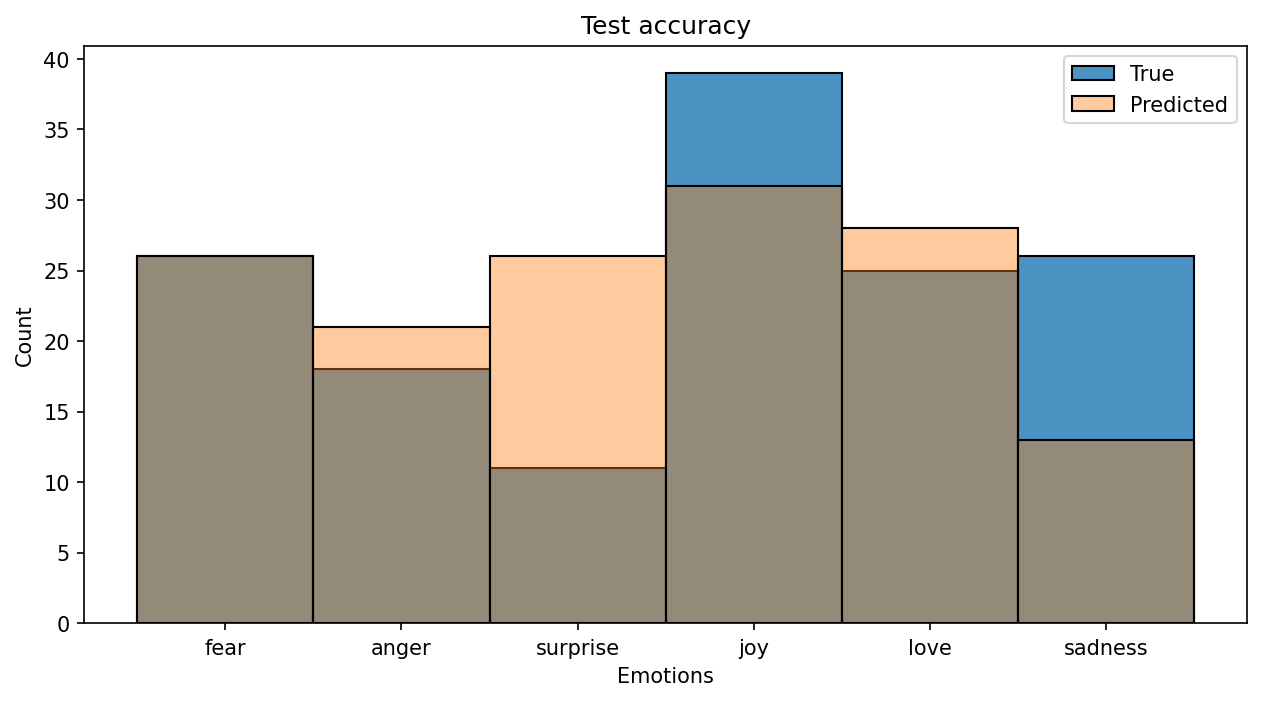

In [24]:
plt.figure(figsize=(10, 5), dpi=150)
plt.title("Test accuracy")
sns.histplot(
    data=error_df,
    x="true_label",
    label="True",
    alpha=0.8,
)
sns.histplot(
    data=error_df,
    x="pred_label",
    label="Predicted",
    alpha=0.4,
)
plt.xlabel("Emotions")
plt.legend()
plt.show()